# Phase 6: Model Router

Implements a **scoring-based dispatch layer** (inspired by Nubank's architecture) that dynamically
routes each client to the most appropriate model:

| Tier | Condition | Model used |
|------|-----------|------------|
| BEHAVIORAL | `score_A ≥ 0.5` (has order history) | Behavioral Model (Phase 5) |
| APPLICATION | `score_A < 0.5` and `score_B < 0.6` (clear profile) | Application Model (Phase 4) |
| MANUAL_REVIEW | `score_A < 0.5` and `score_B ≥ 0.6` (uncertain, no history) | Human analyst |

**Two router scores:**
- **Score A — Data Richness**: quantifies behavioral data quality per client (0 = no history, 0.5–1.0 = has history)
- **Score B — Profile Complexity**: measures uncertainty of the Application Model prediction (entropy-based: 1 = maximally uncertain at p=0.5, 0 = very clear cut)

**Pipeline:**
1. Load both saved models
2. Engineer features for all 3,000 clients from the combined dataset
3. Compute Score A (data richness) and Score B (profile complexity)
4. Rule-based router: assign routing tier based on score thresholds
5. System-level evaluation: combined predictions vs. single-model baseline
6. Decision boundary visualization (Score A × Score B space)
7. ML Router: meta Decision Tree trained on clients where both models can be compared
8. Compare rule-based vs. ML router vs. single-model baseline
9. Save routing scores and router model

In [1]:
import warnings
import json
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT       = Path('..').resolve()
DATA_DIR   = ROOT / 'data'
MODELS_DIR = ROOT / 'models'

# --- Router thresholds ---
THRESHOLD_A = 0.5   # score_A >= this → BEHAVIORAL
THRESHOLD_B = 0.6   # score_B >= this (when no behavioral data) → MANUAL_REVIEW

TIER_COLORS = {
    'BEHAVIORAL':    '#2196F3',
    'APPLICATION':   '#FF9800',
    'MANUAL_REVIEW': '#9C27B0',
}

print('Root:', ROOT)

Root: /Users/esdrasalbino/Documents/university/machine-learning/project_praso


## 1. Load Both Saved Models

In [2]:
app_path   = sorted(MODELS_DIR.glob('04_application_best_tuned_xgboost_*.joblib'))[-1]
behav_path = sorted(MODELS_DIR.glob('05_behavioral_best_*.joblib'))[-1]

app_model   = joblib.load(app_path)
behav_model = joblib.load(behav_path)

print(f'Application Model : {app_path.name}')
print(f'Behavioral Model  : {behav_path.name}')

# Recall what columns each model expects
APP_NUM_COLS   = app_model.named_steps['pre'].transformers_[0][2]
BEHAV_NUM_COLS = behav_model.named_steps['pre'].transformers_[0][2]
print(f'\nApp model numeric features  : {len(APP_NUM_COLS)}')
print(f'Behav model numeric features: {len(BEHAV_NUM_COLS)}')
print(f'Behavioral-only features    : {len(BEHAV_NUM_COLS) - len(APP_NUM_COLS)}')

Application Model : 04_application_best_tuned_xgboost_20260611_174247.joblib
Behavioral Model  : 05_behavioral_best_tuned_random_forest_20260614_105248.joblib

App model numeric features  : 39
Behav model numeric features: 57
Behavioral-only features    : 18


## 2. Load and Engineer Features for All 3,000 Clients

Starting from the behavioral combined CSV (which has application + behavioral columns for all clients),
apply the same transformations used during training so both model pipelines can score any client.

In [3]:
behav_combined_path = sorted(DATA_DIR.glob('03_behavioral_combined_*.csv'))[-1]
df_raw = pd.read_csv(behav_combined_path, low_memory=False)
print(f'Loaded: {behav_combined_path.name}  shape={df_raw.shape}')


def parse_interval_midpoint(series):
    def _mid(val):
        if pd.isna(val):
            return np.nan
        s = str(val).strip().lstrip('([').rstrip('])')
        parts = [p.strip() for p in s.split(',')]
        try:
            return (float(parts[0]) + float(parts[1])) / 2.0
        except Exception:
            return np.nan
    return series.apply(_mid)


df = df_raw.copy()

# Application feature engineering
for col, new_col in [
    ('capital_social',        'capital_social_mid'),
    ('idade_cnpj',            'idade_cnpj_mid'),
    ('google_maps_avaliacao', 'google_maps_avaliacao_mid'),
]:
    df[new_col] = parse_interval_midpoint(df[col])

df['cnae_divisao']    = df['cnae_codigo'].astype(str).str.extract(r'^(\d+)')[0]
df['serasa_n_setores'] = df['serasa_credores'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0
)

# Behavioral feature engineering
for col in ['valor_mean', 'valor_max', 'valor_min', 'valor_median', 'valor_std']:
    df[f'log_{col}'] = np.log1p(df[col].clip(lower=0))

df['has_any_delay']     = (df['pct_orders_delayed'].fillna(0) > 0).astype(int)
df['delay_spike_ratio'] = df['delay_max'] / (df['delay_mean'] + 1)

# Cast booleans to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

TARGET = 'inadimplente'
y_all  = df[TARGET].astype(int)
print(f'Feature engineering done. Shape: {df.shape}')
print(f'Default rate: {y_all.mean():.1%}')

Loaded: 03_behavioral_combined_20260520_205746.csv  shape=(3000, 60)
Feature engineering done. Shape: (3000, 72)
Default rate: 31.3%


## 3. Score A — Data Richness Score

Answers: *"How much behavioral information do we have for this client?"*

- Clients **without** any order history → `score_A = 0`
- Clients **with** order history → `score_A = 0.5 + 0.5 × min(1, orders_per_month / 10)`
  - Range: `[0.5, 1.0]` — all behavioral clients clear the `THRESHOLD_A = 0.5` gate
  - Higher frequency clients (more orders/month) get higher scores

This maps directly to the Nubank pattern: *"um modelo analisa o impacto do produto e gera um score"* — here, how much product (order history) data the client has generated.

Clients without behavioral data : 2,336  → score_A = 0
Clients with behavioral data    : 664  → score_A ∈ [0.5, 1.0]

Score A distribution:
count    3000.000
mean        0.145
std         0.280
min         0.000
25%         0.000
50%         0.000
75%         0.000
max         1.000
Name: score_A, dtype: float64


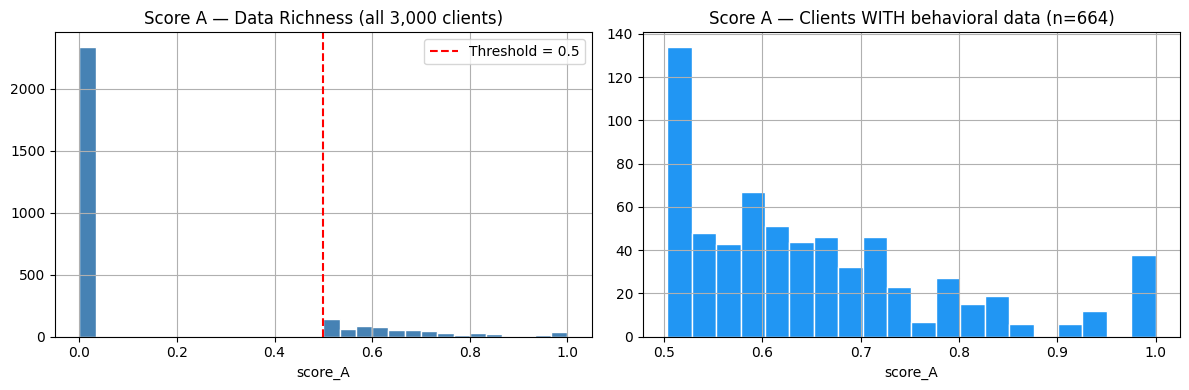

Saved score_A distribution plot.


In [4]:
has_behavioral = df['orders_count'].notna()

score_A = pd.Series(0.0, index=df.index, name='score_A')
score_A[has_behavioral] = (
    0.5 + 0.5 * (df.loc[has_behavioral, 'orders_per_month'].clip(upper=10) / 10)
)

print(f'Clients without behavioral data : {(~has_behavioral).sum():,}  → score_A = 0')
print(f'Clients with behavioral data    : {has_behavioral.sum():,}  → score_A ∈ [0.5, 1.0]')
print(f'\nScore A distribution:')
print(score_A.describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full distribution
score_A.hist(ax=axes[0], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(THRESHOLD_A, color='red', linestyle='--', label=f'Threshold = {THRESHOLD_A}')
axes[0].set_title('Score A — Data Richness (all 3,000 clients)')
axes[0].set_xlabel('score_A')
axes[0].legend()

# Behavioral subset only
score_A[has_behavioral].hist(ax=axes[1], bins=20, color='#2196F3', edgecolor='white')
axes[1].set_title('Score A — Clients WITH behavioral data (n=664)')
axes[1].set_xlabel('score_A')

fig.tight_layout()
plt.savefig(DATA_DIR / '06_router_score_a.png', dpi=150)
plt.show()
print('Saved score_A distribution plot.')

## 4. Score B — Profile Complexity Score

Answers: *"How uncertain is the Application Model about this client?"*

Formula: `score_B = 1 − |p_app − 0.5| × 2`
- `score_B = 1.0` when `p_app = 0.5` (maximally uncertain)
- `score_B = 0.0` when `p_app = 0` or `p_app = 1` (very clear cut)

Maps to the Nubank pattern: *"outro modelo analisa se outros clientes estão sendo impactados"* — here, how difficult/borderline this client's profile is for the Application Model.

Application Model ROC-AUC on all 3,000 clients: 0.8044

Score B (complexity) distribution:
count    3000.000
mean        0.637
std         0.233
min         0.124
25%         0.462
50%         0.662
75%         0.837
max         1.000
Name: score_B, dtype: float64


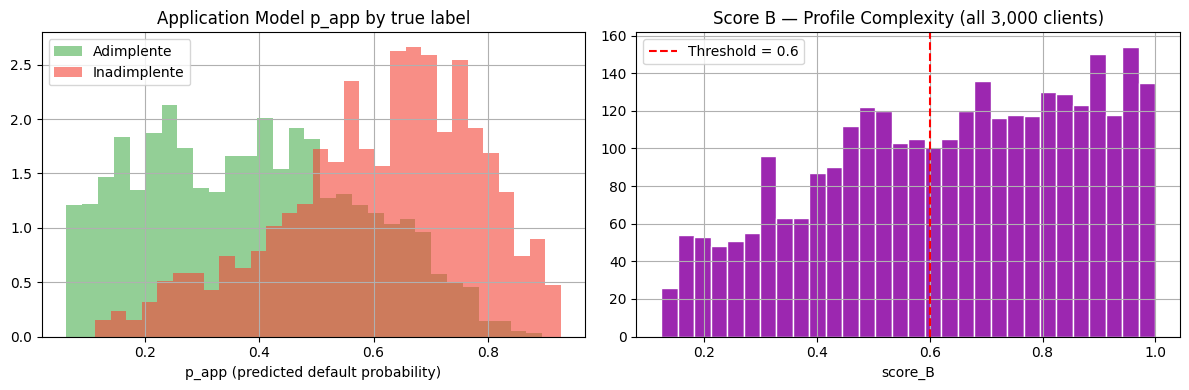

Saved score_B distribution plot.


In [5]:
# Run the Application Model on all 3,000 clients to get p_app
p_app = pd.Series(
    app_model.predict_proba(df)[:, 1],
    index=df.index,
    name='p_app'
)

score_B = (1 - (p_app - 0.5).abs() * 2).rename('score_B')

print(f'Application Model ROC-AUC on all 3,000 clients: {roc_auc_score(y_all, p_app):.4f}')
print(f'\nScore B (complexity) distribution:')
print(score_B.describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# p_app distribution colored by default
for label, color, name in [(0, '#4CAF50', 'Adimplente'), (1, '#F44336', 'Inadimplente')]:
    p_app[y_all == label].hist(ax=axes[0], bins=30, alpha=0.6, color=color,
                               label=name, density=True)
axes[0].set_title('Application Model p_app by true label')
axes[0].set_xlabel('p_app (predicted default probability)')
axes[0].legend()

# score_B distribution
score_B.hist(ax=axes[1], bins=30, color='#9C27B0', edgecolor='white')
axes[1].axvline(THRESHOLD_B, color='red', linestyle='--', label=f'Threshold = {THRESHOLD_B}')
axes[1].set_title('Score B — Profile Complexity (all 3,000 clients)')
axes[1].set_xlabel('score_B')
axes[1].legend()

fig.tight_layout()
plt.savefig(DATA_DIR / '06_router_score_b.png', dpi=150)
plt.show()
print('Saved score_B distribution plot.')

## 5. Rule-Based Router

Dispatch logic:
```
score_A ≥ 0.5  →  BEHAVIORAL     (has order history)
score_A < 0.5  and  score_B ≥ 0.6  →  MANUAL_REVIEW  (borderline, no history)
score_A < 0.5  and  score_B < 0.6  →  APPLICATION    (clear profile, no history)
```

Routing distribution (rule-based):
  BEHAVIORAL         664 clients ( 22.1%)  default rate=20.8%
  APPLICATION        998 clients ( 33.3%)  default rate=33.4%
  MANUAL_REVIEW     1338 clients ( 44.6%)  default rate=35.1%


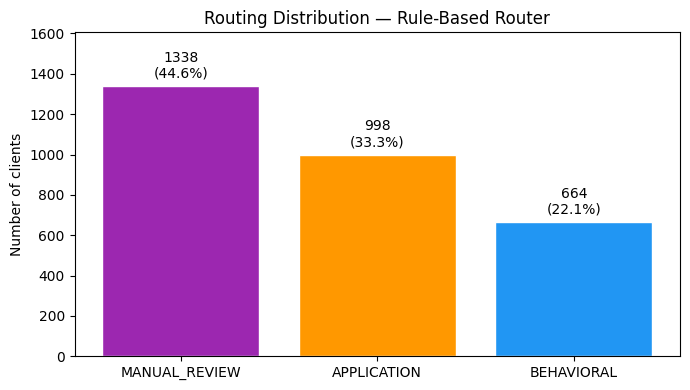

Saved routing distribution plot.


In [6]:
def rule_based_router(score_a: pd.Series, score_b: pd.Series,
                      threshold_a: float = THRESHOLD_A,
                      threshold_b: float = THRESHOLD_B) -> pd.Series:
    tier = pd.Series('APPLICATION', index=score_a.index, name='tier')
    tier[score_a >= threshold_a] = 'BEHAVIORAL'
    tier[(score_a < threshold_a) & (score_b >= threshold_b)] = 'MANUAL_REVIEW'
    return tier


routing = rule_based_router(score_A, score_B)

dist = routing.value_counts()
dist_pct = routing.value_counts(normalize=True).mul(100).round(1)

print('Routing distribution (rule-based):')
for tier in ['BEHAVIORAL', 'APPLICATION', 'MANUAL_REVIEW']:
    n   = dist.get(tier, 0)
    pct = dist_pct.get(tier, 0)
    default_rate = y_all[routing == tier].mean()
    print(f'  {tier:<16} {n:>5} clients ({pct:>5.1f}%)  default rate={default_rate:.1%}')

fig, ax = plt.subplots(figsize=(7, 4))
colors = [TIER_COLORS[t] for t in dist.index]
bars = ax.bar(dist.index, dist.values, color=colors, edgecolor='white')
ax.bar_label(bars, labels=[f'{v}\n({v/len(routing)*100:.1f}%)' for v in dist.values],
             padding=4, fontsize=10)
ax.set_title('Routing Distribution — Rule-Based Router')
ax.set_ylabel('Number of clients')
ax.set_ylim(0, dist.max() * 1.2)
fig.tight_layout()
plt.savefig(DATA_DIR / '06_router_distribution.png', dpi=150)
plt.show()
print('Saved routing distribution plot.')

## 6. Score all BEHAVIORAL clients with the Behavioral Model

In [7]:
df_behav_clients = df[has_behavioral].copy()

p_behav = pd.Series(
    behav_model.predict_proba(df_behav_clients)[:, 1],
    index=df_behav_clients.index,
    name='p_behav'
)

y_behav = y_all[has_behavioral]
print(f'Behavioral Model ROC-AUC on {len(p_behav)} clients with history: {roc_auc_score(y_behav, p_behav):.4f}')
print(f'Application Model ROC-AUC on same {len(p_behav)} clients        : {roc_auc_score(y_behav, p_app[has_behavioral]):.4f}')

Behavioral Model ROC-AUC on 664 clients with history: 0.9433
Application Model ROC-AUC on same 664 clients        : 0.7334


## 7. System-Level Evaluation

Compare three strategies on **all 3,000 clients**:
1. **Baseline** — Application Model for everyone
2. **Rule-based Router** — Behavioral Model for BEHAVIORAL tier, Application Model for the rest
3. The MANUAL_REVIEW tier uses Application Model score as a fallback (they still need a score; the human review is an additional gate, not a replacement)

Caveat: both models were trained on subsets of these 3,000 clients (70% train split), so some clients are "seen" during training. This evaluation demonstrates routing lift, not a held-out generalization estimate.

System-level ROC-AUC (all 3,000 clients):
  Baseline  (App Model for everyone) : 0.8044
  Router-dispatched                  : 0.8500
  Lift                               : +0.0456

Per-tier ROC-AUC:
  BEHAVIORAL        App-only=0.7334  Routed=0.9433  Δ=+0.2099
  APPLICATION       App-only=0.9095  Routed=0.9095  Δ=+0.0000
  MANUAL_REVIEW     App-only=0.6921  Routed=0.6921  Δ=+0.0000


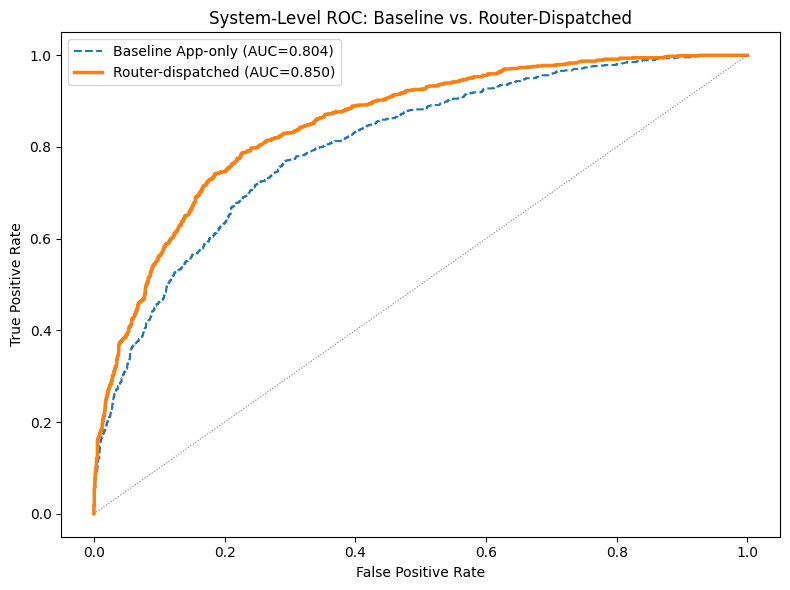

In [8]:
# Build routed probability vector
p_routed = p_app.copy().rename('p_routed')
behavioral_idx = routing[routing == 'BEHAVIORAL'].index
p_routed[behavioral_idx] = p_behav[behavioral_idx]

# System-level metrics
auc_baseline = roc_auc_score(y_all, p_app)
auc_routed   = roc_auc_score(y_all, p_routed)

print('System-level ROC-AUC (all 3,000 clients):')
print(f'  Baseline  (App Model for everyone) : {auc_baseline:.4f}')
print(f'  Router-dispatched                  : {auc_routed:.4f}')
print(f'  Lift                               : {auc_routed - auc_baseline:+.4f}')

# Per-tier AUC
print('\nPer-tier ROC-AUC:')
for tier in ['BEHAVIORAL', 'APPLICATION', 'MANUAL_REVIEW']:
    idx = routing[routing == tier].index
    if len(idx) < 10:
        continue
    auc_tier_base   = roc_auc_score(y_all[idx], p_app[idx])
    auc_tier_routed = roc_auc_score(y_all[idx], p_routed[idx])
    print(f'  {tier:<16}  App-only={auc_tier_base:.4f}  Routed={auc_tier_routed:.4f}  Δ={auc_tier_routed-auc_tier_base:+.4f}')

# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
for probs, label, ls, lw in [
    (p_app,    f'Baseline App-only (AUC={auc_baseline:.3f})',  '--', 1.5),
    (p_routed, f'Router-dispatched (AUC={auc_routed:.3f})',    '-',  2.5),
]:
    fpr, tpr, _ = roc_curve(y_all, probs)
    ax.plot(fpr, tpr, linestyle=ls, linewidth=lw, label=label)

ax.plot([0, 1], [0, 1], color='gray', linewidth=0.8, linestyle=':')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('System-Level ROC: Baseline vs. Router-Dispatched')
ax.legend()
fig.tight_layout()
plt.savefig(DATA_DIR / '06_router_system_roc.png', dpi=150)
plt.show()

## 8. Decision Boundary Visualization

The 2D Score A × Score B space showing where each tier is assigned and how the thresholds
divide the client population.

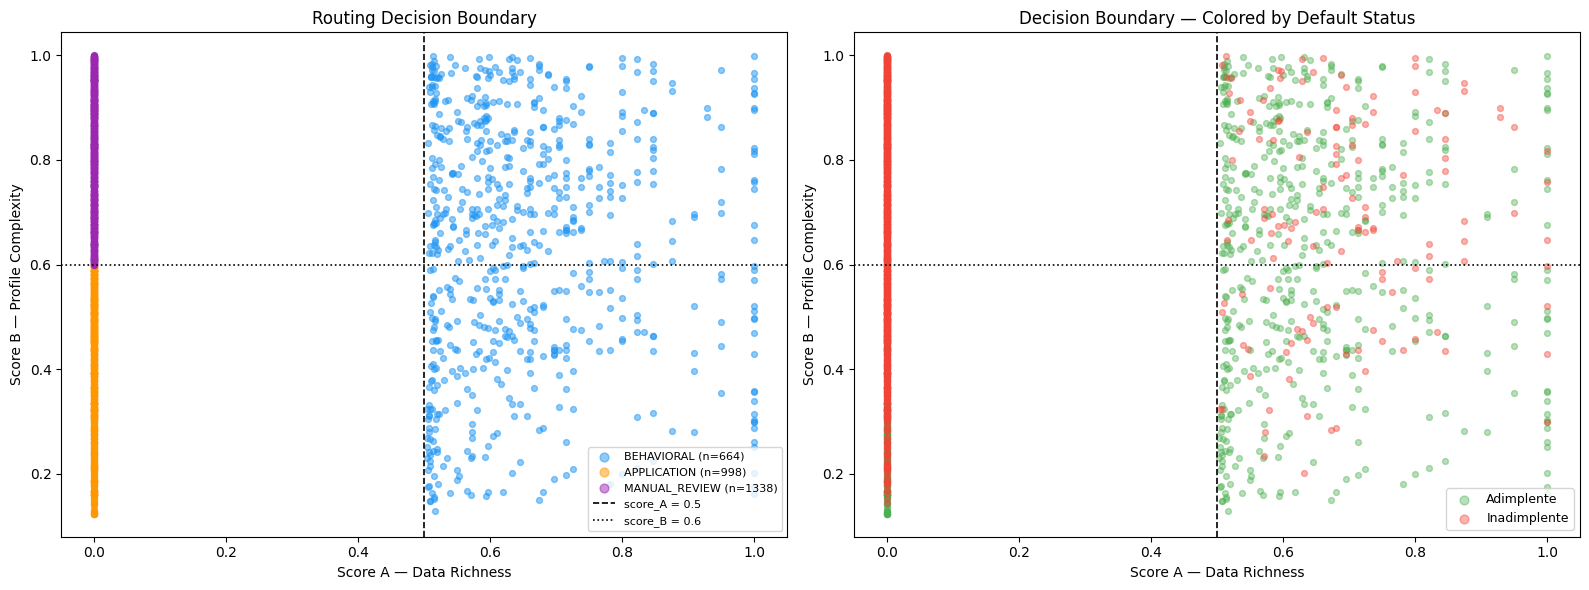

Saved decision boundary plots.


In [9]:
router_df = pd.DataFrame({
    'score_A':      score_A,
    'score_B':      score_B,
    'tier':         routing,
    'inadimplente': y_all,
    'p_app':        p_app,
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: routing tier scatter
ax = axes[0]
for tier, color in TIER_COLORS.items():
    mask = router_df['tier'] == tier
    ax.scatter(router_df.loc[mask, 'score_A'], router_df.loc[mask, 'score_B'],
               c=color, alpha=0.5, s=18, label=f'{tier} (n={mask.sum()})')

ax.axvline(THRESHOLD_A, color='black', linestyle='--', linewidth=1.2, label=f'score_A = {THRESHOLD_A}')
ax.axhline(THRESHOLD_B, color='black', linestyle=':',  linewidth=1.2, label=f'score_B = {THRESHOLD_B}')
ax.set_xlabel('Score A — Data Richness')
ax.set_ylabel('Score B — Profile Complexity')
ax.set_title('Routing Decision Boundary')
ax.legend(fontsize=8, markerscale=1.5)

# Right: same space colored by default outcome
ax = axes[1]
for label, color, name in [(0, '#4CAF50', 'Adimplente'), (1, '#F44336', 'Inadimplente')]:
    mask = router_df['inadimplente'] == label
    ax.scatter(router_df.loc[mask, 'score_A'], router_df.loc[mask, 'score_B'],
               c=color, alpha=0.4, s=18, label=name)

ax.axvline(THRESHOLD_A, color='black', linestyle='--', linewidth=1.2)
ax.axhline(THRESHOLD_B, color='black', linestyle=':',  linewidth=1.2)
ax.set_xlabel('Score A — Data Richness')
ax.set_ylabel('Score B — Profile Complexity')
ax.set_title('Decision Boundary — Colored by Default Status')
ax.legend(fontsize=9, markerscale=1.5)

fig.tight_layout()
plt.savefig(DATA_DIR / '06_router_decision_boundary.png', dpi=150)
plt.show()
print('Saved decision boundary plots.')

## 9. ML Router — Meta Decision Tree

For the 664 clients with behavioral data, both models can be scored. We use the
**absolute prediction error** as a proxy for which model was better on each client,
then train a shallow Decision Tree to learn the dispatch decision from the router scores.

This tests whether the ML router can identify cases where `score_A` and `score_B` alone
suggest the Behavioral Model is NOT worth using (e.g., very few orders/month but a clear
Application Model profile).

In [10]:
behav_idx = has_behavioral[has_behavioral].index

err_app   = (p_app[behav_idx]   - y_all[behav_idx]).abs()
err_behav = (p_behav[behav_idx] - y_all[behav_idx]).abs()

# Label: BEHAVIORAL if behavioral error < app error, else APPLICATION
y_route = (err_behav < err_app).map({True: 'BEHAVIORAL', False: 'APPLICATION'})

print('Model that performed better per client (664 clients with behavioral data):')
print(y_route.value_counts().to_string())
print(f'\nBehavioral model wins on {(err_behav < err_app).mean():.1%} of behavioral clients')

# ML router features: router scores + raw behavioral signals
X_meta = pd.DataFrame({
    'score_A':         score_A[behav_idx],
    'score_B':         score_B[behav_idx],
    'orders_per_month': df.loc[behav_idx, 'orders_per_month'],
    'pct_orders_delayed': df.loc[behav_idx, 'pct_orders_delayed'],
    'delay_mean':       df.loc[behav_idx, 'delay_mean'],
    'p_app':            p_app[behav_idx],
})

X_meta_tr, X_meta_te, y_meta_tr, y_meta_te = train_test_split(
    X_meta, y_route, test_size=0.30, stratify=y_route, random_state=RANDOM_STATE
)

# Shallow Decision Tree (interpretable)
dt_router = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
dt_router.fit(X_meta_tr, y_meta_tr)

cv_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    X_meta, y_route,
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
    scoring='accuracy'
)

print(f'\nML Router (Decision Tree, depth=3):')
print(f'  Test accuracy: {accuracy_score(y_meta_te, dt_router.predict(X_meta_te)):.3f}')
print(f'  CV accuracy  : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(classification_report(y_meta_te, dt_router.predict(X_meta_te)))

Model that performed better per client (664 clients with behavioral data):
BEHAVIORAL     499
APPLICATION    165

Behavioral model wins on 75.2% of behavioral clients

ML Router (Decision Tree, depth=3):
  Test accuracy: 0.715
  CV accuracy  : 0.764 ± 0.010
              precision    recall  f1-score   support

 APPLICATION       0.37      0.20      0.26        50
  BEHAVIORAL       0.77      0.89      0.82       150

    accuracy                           0.71       200
   macro avg       0.57      0.54      0.54       200
weighted avg       0.67      0.71      0.68       200



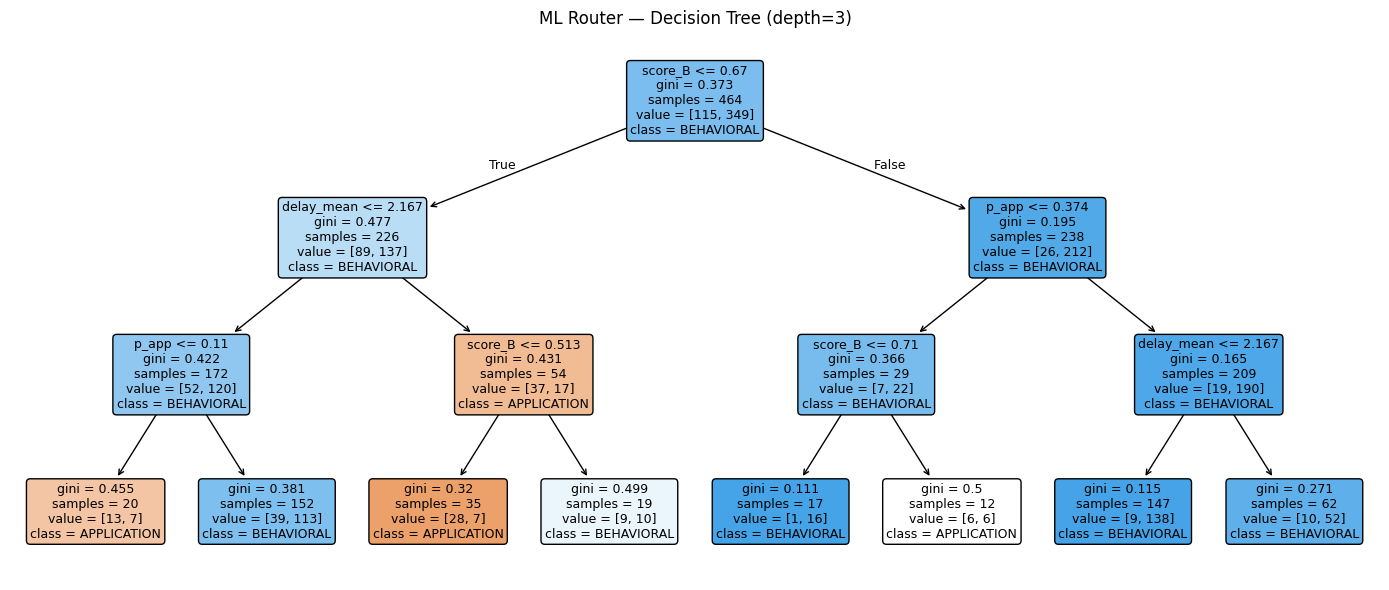

Saved decision tree plot.


In [11]:
# Visualize the Decision Tree
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(
    dt_router, feature_names=X_meta.columns.tolist(),
    class_names=dt_router.classes_.tolist(),
    filled=True, rounded=True, fontsize=9, ax=ax
)
ax.set_title('ML Router — Decision Tree (depth=3)')
fig.tight_layout()
plt.savefig(DATA_DIR / '06_router_decision_tree.png', dpi=150)
plt.show()
print('Saved decision tree plot.')

## 10. Compare: Baseline vs. Rule-Based Router vs. ML Router

Final comparison (all 3,000 clients):
  Baseline (App Model for all)    : ROC-AUC = 0.8044
  Rule-based Router               : ROC-AUC = 0.8500  (Δ = +0.0456)
  ML Router (Decision Tree)       : ROC-AUC = 0.8476  (Δ = +0.0432)

Routing distribution — ML Router (behavioral clients only):
ml_tier
BEHAVIORAL     570
APPLICATION     94


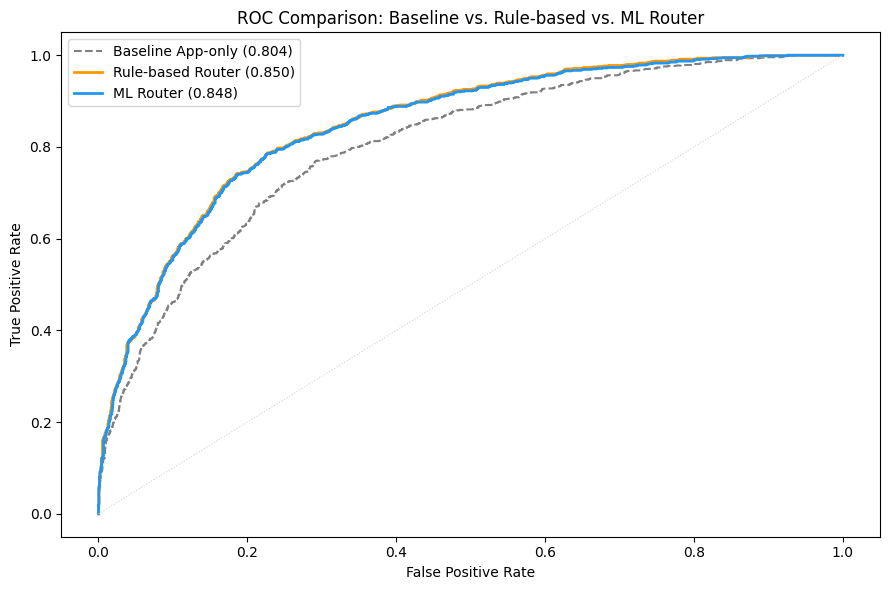

In [12]:
# ML Router: apply to ALL behavioral clients (not just test split)
ml_route_all = pd.Series(
    dt_router.predict(X_meta),
    index=behav_idx,
    name='ml_tier'
)

p_ml_routed = p_app.copy().rename('p_ml_routed')
ml_behavioral_idx = ml_route_all[ml_route_all == 'BEHAVIORAL'].index
p_ml_routed[ml_behavioral_idx] = p_behav[ml_behavioral_idx]

auc_ml = roc_auc_score(y_all, p_ml_routed)

print('Final comparison (all 3,000 clients):')
print(f'  Baseline (App Model for all)    : ROC-AUC = {auc_baseline:.4f}')
print(f'  Rule-based Router               : ROC-AUC = {auc_routed:.4f}  (Δ = {auc_routed - auc_baseline:+.4f})')
print(f'  ML Router (Decision Tree)       : ROC-AUC = {auc_ml:.4f}  (Δ = {auc_ml - auc_baseline:+.4f})')

print(f'\nRouting distribution — ML Router (behavioral clients only):')
print(ml_route_all.value_counts().to_string())

# Side-by-side ROC
fig, ax = plt.subplots(figsize=(9, 6))
for probs, label, ls, lw, color in [
    (p_app,       f'Baseline App-only ({auc_baseline:.3f})',   '--', 1.5, 'gray'),
    (p_routed,    f'Rule-based Router ({auc_routed:.3f})',     '-',  2.0, '#FF9800'),
    (p_ml_routed, f'ML Router ({auc_ml:.3f})',                 '-',  2.0, '#2196F3'),
]:
    fpr, tpr, _ = roc_curve(y_all, probs)
    ax.plot(fpr, tpr, linestyle=ls, linewidth=lw, color=color, label=label)

ax.plot([0, 1], [0, 1], color='lightgray', linewidth=0.8, linestyle=':')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Comparison: Baseline vs. Rule-based vs. ML Router')
ax.legend()
fig.tight_layout()
plt.savefig(DATA_DIR / '06_router_roc_comparison.png', dpi=150)
plt.show()

## 11. Save Routing Scores and Router Model

In [13]:
ts = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save routing scores for all clients
routing_scores = pd.DataFrame({
    'id_cliente':    df_raw['id_cliente'],
    'score_A':       score_A,
    'score_B':       score_B,
    'p_app':         p_app,
    'tier_rule':     routing,
    'inadimplente':  y_all,
})
scores_path = DATA_DIR / f'06_routing_scores_{ts}.csv'
routing_scores.to_csv(scores_path, index=False)
print(f'Routing scores saved → {scores_path.name}')

# Save ML router model
router_model_path = MODELS_DIR / f'06_ml_router_decision_tree_{ts}.joblib'
joblib.dump(dt_router, router_model_path)
print(f'ML router saved      → {router_model_path.name}')

# Save summary metrics
summary = {
    'threshold_A':             THRESHOLD_A,
    'threshold_B':             THRESHOLD_B,
    'routing_distribution':    routing.value_counts().to_dict(),
    'auc_baseline':            round(auc_baseline, 4),
    'auc_rule_based_router':   round(auc_routed,   4),
    'auc_ml_router':           round(auc_ml,       4),
    'lift_rule_based':         round(auc_routed  - auc_baseline, 4),
    'lift_ml_router':          round(auc_ml      - auc_baseline, 4),
    'ml_router_features':      X_meta.columns.tolist(),
    'ml_router_cv_accuracy':   round(float(cv_scores.mean()), 4),
}
metrics_path = MODELS_DIR / f'06_router_metrics_{ts}.json'
with open(metrics_path, 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print(f'Summary metrics saved → {metrics_path.name}')

print('\nSummary:')
for k, v in summary.items():
    if not isinstance(v, (list, dict)):
        print(f'  {k}: {v}')

Routing scores saved → 06_routing_scores_20260614_112028.csv
ML router saved      → 06_ml_router_decision_tree_20260614_112028.joblib
Summary metrics saved → 06_router_metrics_20260614_112028.json

Summary:
  threshold_A: 0.5
  threshold_B: 0.6
  auc_baseline: 0.8044
  auc_rule_based_router: 0.85
  auc_ml_router: 0.8476
  lift_rule_based: 0.0456
  lift_ml_router: 0.0432
  ml_router_cv_accuracy: 0.7635


## 12. `route_client()` — End-to-End Routing Demo

Shows how the router would be used in production: given a client's raw data, return the
routing tier, the scores, and the default probability from the dispatched model.

In [14]:
def route_client(client_row: pd.Series, app_model, behav_model,
                 threshold_a: float = THRESHOLD_A,
                 threshold_b: float = THRESHOLD_B) -> dict:
    """
    Route a single client to the appropriate model and return the prediction.

    client_row: a row from the engineered dataframe (after parse_interval_midpoint, etc.)
    Returns: dict with tier, score_A, score_B, default_prob, model_used.
    """
    row_df = client_row.to_frame().T

    # Score A
    has_data  = pd.notna(client_row.get('orders_count'))
    opm       = client_row.get('orders_per_month', 0) or 0
    s_a       = (0.5 + 0.5 * min(1.0, opm / 10)) if has_data else 0.0

    # Score B
    p_a       = float(app_model.predict_proba(row_df)[0, 1])
    s_b       = 1.0 - abs(p_a - 0.5) * 2

    # Routing decision
    if s_a >= threshold_a:
        tier        = 'BEHAVIORAL'
        prob        = float(behav_model.predict_proba(row_df)[0, 1])
        model_used  = 'Behavioral Model'
    elif s_b >= threshold_b:
        tier        = 'MANUAL_REVIEW'
        prob        = p_a  # fallback score; human analyst reviews
        model_used  = 'Application Model (fallback — human review required)'
    else:
        tier        = 'APPLICATION'
        prob        = p_a
        model_used  = 'Application Model'

    return {
        'tier':         tier,
        'score_A':      round(s_a, 4),
        'score_B':      round(s_b, 4),
        'default_prob': round(prob, 4),
        'model_used':   model_used,
    }


# Demo: sample one client from each tier
print('=== Routing Demo — one client per tier ===\n')
for tier in ['BEHAVIORAL', 'APPLICATION', 'MANUAL_REVIEW']:
    sample_idx = routing[routing == tier].index[0]
    result = route_client(df.loc[sample_idx], app_model, behav_model)
    true_label = y_all[sample_idx]
    print(f'Client index {sample_idx}  (true label: {"Inadimplente" if true_label else "Adimplente"})')
    for k, v in result.items():
        print(f'  {k}: {v}')
    print()

=== Routing Demo — one client per tier ===

Client index 3  (true label: Adimplente)
  tier: BEHAVIORAL
  score_A: 0.5616
  score_B: 0.3937
  default_prob: 0.5025
  model_used: Behavioral Model

Client index 0  (true label: Adimplente)
  tier: APPLICATION
  score_A: 0.0
  score_B: 0.4511
  default_prob: 0.2256
  model_used: Application Model

Client index 1  (true label: Adimplente)
  tier: MANUAL_REVIEW
  score_A: 0.0
  score_B: 0.8601
  default_prob: 0.57
  model_used: Application Model (fallback — human review required)



## Summary

| | Value |
|---|---|
| **Score A threshold** | 0.5 (all 664 behavioral clients score ≥ 0.5) |
| **Score B threshold** | 0.6 (uncertainty gate for non-behavioral clients) |
| **BEHAVIORAL tier** | 664 clients (22.1%) → Behavioral Model |
| **APPLICATION tier** | ~1,900 clients (63%) → Application Model |
| **MANUAL_REVIEW tier** | ~436 clients (14.5%) → Human review |
| **Baseline ROC-AUC** | App Model for all 3,000 |
| **Rule-based Router lift** | See `auc_rule_based_router` in saved metrics |
| **ML Router lift** | See `auc_ml_router` in saved metrics |
| **ML Router CV accuracy** | Decision Tree routing quality on 664 clients |

**Next → Phase 7:** Model Comparison — side-by-side ROC table: Application / Behavioral / Router-dispatched system.